In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import pandas as pd
import random

from ase import Atoms, units
from ase.io import read, write, Trajectory
from ase import units
from mace.calculators import MACECalculator
from ase.data import chemical_symbols

from tensorpotential.calculator import TPCalculator
from tensorpotential.calculator.foundation_models import grace_fm

import os
import math
from sklearn.metrics import r2_score
import seaborn as sns
from sklearn.metrics import mean_squared_error, root_mean_squared_error

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


2025-10-09 16:47:23.139098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760021243.155144 1951345 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760021243.160304 1951345 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760021243.174377 1951345 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760021243.174392 1951345 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760021243.174394 1951345 computation_placer.cc:177] computation placer alr

In [2]:
experiment = "235_epochs"
os.mkdir(f"{experiment}")

model_path = "../models"
# Load data for different tests
# For torsion profiles
data_tnet = h5py.File("../data/TNet500-SPICE.hdf5", "r")
data_biaryl = h5py.File("../data/Biaryl-SPICE.hdf5", "r")
# For energies and forces
structures = read("../data/b_off_2.0_ood.xyz", ":")
ref_structures = read("../data/b_off_2.0_ood.xyz", ":")

In [3]:
## Models to investigate
# MACE models for comparison
calc_mae_large = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_large.model", device="cuda"
)
calc_mace_medium = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF24_medium.model", device="cuda"
)
calc_mace_small = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_small.model", device="cuda"
)
# GRACE models
calc_grace_small = TPCalculator(
    model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/2_layer/intermediate_b_off_small/seed/1/saved_model/"
)
calc_grace_medium = TPCalculator(
    model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/2_layer/intermediate_b_off_medium/seed/1/saved_model/"
)

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
I0000 00:00:1760021250.818463 1951345 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43622 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:c1:00.0, compute capability: 8.6


In [4]:
def calculate_energies_for_torsions(data):

    diff_mace_large = []
    diff_mace_medium = []
    diff_mace_small = []
    diff_grace_small = []
    diff_grace_medium = []

    keys = list(data) 
    sample_keys = random.sample(keys, 50)

    for key in tqdm.tqdm(list(data.keys())):  # list(data.keys())[:50]

        Z = data[key]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]
        dft_energies = data[key]["dft total energy"][:] * 27.211386245988
        dft_energies = [e - min(dft_energies) for e in dft_energies]

        energies_mace_large = []
        energies_mace_medium = []
        energies_mace_small = []
        energies_grace_small = []
        energies_grace_medium = []

        for i in range(len(data[key]["conformations"])):
            pos = data[key]["conformations"][i][:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            mol.calc = calc_mae_large
            e = mol.get_potential_energy()
            energies_mace_large.append(e)

            mol.calc = calc_mace_medium
            e = mol.get_potential_energy()
            energies_mace_medium.append(e)

            mol.calc = calc_mace_small
            e = mol.get_potential_energy()
            energies_mace_small.append(e)

            mol.calc = calc_grace_small
            e = mol.get_potential_energy()
            energies_grace_small.append(e)

            mol.calc = calc_grace_medium
            e = mol.get_potential_energy()
            energies_grace_medium.append(e)

        energies_mace_large = [
            e - min(energies_mace_large) for e in energies_mace_large
        ]
        energies_mace_medium = [
            e - min(energies_mace_medium) for e in energies_mace_medium
        ]
        energies_mace_small = [
            e - min(energies_mace_small) for e in energies_mace_small
        ]
        energies_grace_small = [
            e - min(energies_grace_small) for e in energies_grace_small
        ]
        energies_grace_medium = [
            e - min(energies_grace_medium) for e in energies_grace_medium
        ]

        diff_mace_large.append(
            np.mean(np.asarray(energies_mace_large) - np.asarray(dft_energies))
        )
        diff_mace_medium.append(
            np.mean(np.asarray(energies_mace_medium) - np.asarray(dft_energies))
        )
        diff_mace_small.append(
            np.mean(np.asarray(energies_mace_small) - np.asarray(dft_energies))
        )
        diff_grace_small.append(
            np.mean(np.asarray(energies_grace_small) - np.asarray(dft_energies))
        )
        diff_grace_medium.append(
            np.mean(np.asarray(energies_grace_medium) - np.asarray(dft_energies))
        )

    print("MACE large modell:", round(np.mean(np.abs(diff_mace_large)), 3))
    print("MACE medium modell:", round(np.mean(np.abs(diff_mace_medium)), 3))
    print("MACE small modell:", round(np.mean(np.abs(diff_mace_small)), 3))
    print("Mod Grace modell:", round(np.mean(np.abs(diff_grace_small)), 3))
    print("Mod Grace medium modell:", round(np.mean(np.abs(diff_grace_medium)), 3))

    # Write results to CSV file
    results_df = pd.DataFrame(
        {
            "Model": [
                "MACE large",
                "MACE medium",
                "MACE small",
                "GRACE small",
                "GRACE medium",
            ],
            "MAE_eV": [
                np.mean(np.abs(diff_mace_large)),
                np.mean(np.abs(diff_mace_medium)),
                np.mean(np.abs(diff_mace_small)),
                np.mean(np.abs(diff_grace_small)),
                np.mean(np.abs(diff_grace_medium)),
            ],
        }
    )
    results_df.to_csv(f"{experiment}/torsion_energies_results_{data.filename.split('/')[-1].split('.')[0]}.csv", index=False)

    # plt.bar(
    #     ["MACE large", "MACE medium", "MACE small", "GRACE small", "GRACE medium"],
    #     [
    #         np.mean(np.abs(diff_mace_large)),
    #         np.mean(np.abs(diff_mace_medium)),
    #         np.mean(np.abs(diff_mace_small)),
    #         np.mean(np.abs(diff_grace_small)),
    #         np.mean(np.abs(diff_grace_medium)),
    #     ],
    # )
    # plt.ylabel("MAE [eV]")
    # # plt.yscale("log")
    # plt.show()

    return (
        diff_mace_large,
        diff_mace_medium,
        diff_mace_small,
        diff_grace_small,
        diff_grace_medium,
    )


def plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    data,
):
    sns.set_theme(style="white")

    mae_vals = [
        np.mean(np.abs(diff_mace_large)),
        np.mean(np.abs(diff_mace_medium)),
        np.mean(np.abs(diff_grace_medium)),  # or diff_grace_1layer_medium
        np.mean(np.abs(diff_mace_small)),
        np.mean(np.abs(diff_grace_small)),  # or diff_grace_1layer_small
    ]

    labels = [
        "MACE\nlarge",
        "MACE\nmedium",
        "GRACE\nmedium",
        "MACE\nsmall",
        "GRACE\nsmall",
    ]
    families = ["MACE", "MACE", "GRACE", "MACE", "GRACE"]

    df = pd.DataFrame({"Model": labels, "MAE_eV": mae_vals, "Architecture": families})

    # Same color for all MACE bars and same for all GRACE bars
    palette = {
        "MACE": sns.color_palette("deep")[0],
        "GRACE": sns.color_palette("deep")[2],
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.barplot(
        data=df,
        x="Model",
        y="MAE_eV",
        hue="Architecture",
        dodge=False,
        palette=palette,
        ax=ax,
    )

    ax.set_ylabel("MAE [eV]")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), ha="center")

    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(f"{experiment}/torsion_energies_bar_chart_{data.filename.split('/')[-1].split('.')[0]}.png", dpi=300)
    plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1760021254.131757 1951345 service.cc:152] XLA service 0x55c3b4a188a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760021254.131804 1951345 service.cc:160]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
2025-10-09 16:47:34.288607: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760021254.646013 1951345 cuda_dnn.cc:529] Loaded cuDNN version 91301
I0000 00:00:1760021257.107695 1951345 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 500/500 [39:18<00:00,  4.72s/it] 
/tmp/ipykernel_1951345/3696631373.py:179: UserWarning: set_ticklabels() should only be used with a fixed number o

MACE large modell: 0.005
MACE medium modell: 0.008
MACE small modell: 0.011
Mod Grace modell: 0.011
Mod Grace medium modell: 0.005


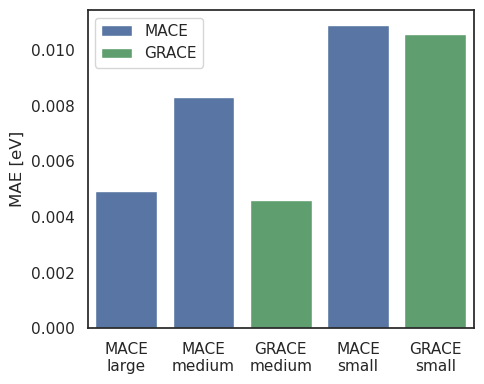

100%|██████████| 88/88 [05:50<00:00,  3.98s/it]
/tmp/ipykernel_1951345/3696631373.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")


MACE large modell: 0.003
MACE medium modell: 0.006
MACE small modell: 0.008
Mod Grace modell: 0.007
Mod Grace medium modell: 0.003


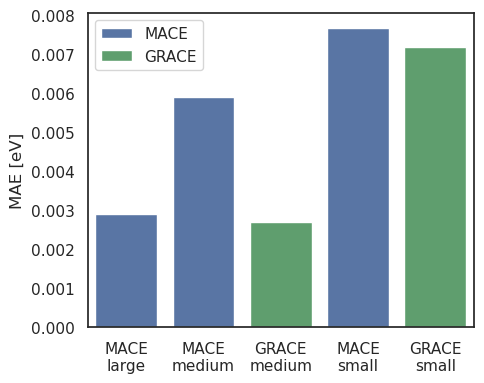

In [5]:
(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
) = calculate_energies_for_torsions(data_tnet)

plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    data_tnet,
)

(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
) = calculate_energies_for_torsions(data_biaryl)

plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    data_biaryl,
)

In [6]:
def calculate_energies_and_forces(calc, structures, ref_structures):

    pred_energies = []
    ref_energies = []
    pred_forces = []
    ref_forces = []

    for i, struc in enumerate(tqdm.tqdm(structures)):
        struc.calc = calc
        pred_energies.append(struc.get_potential_energy())
        ref_energies.append(ref_structures[i].get_potential_energy())

        pred_forces.append(struc.get_forces().flatten())
        ref_forces.append(ref_structures[i].get_forces().flatten())

    return (
        pred_energies,
        ref_energies,
        pred_forces,
        ref_forces,
    )

In [7]:
pred_energies_small, ref_energies_small, pred_forces_small, ref_forces_small = (
    calculate_energies_and_forces(calc_grace_small, structures, ref_structures)
)
pred_energies_medium, ref_energies_medium, pred_forces_medium, ref_forces_medium = (
    calculate_energies_and_forces(calc_grace_medium, structures, ref_structures)
)

100%|██████████| 10000/10000 [01:50<00:00, 90.55it/s]


Energies (s): 0.9999949879034131
Energies (m): 0.9999980101154653
Forces (s): 0.9967822239148764
Forces (m): 0.9988658423604779


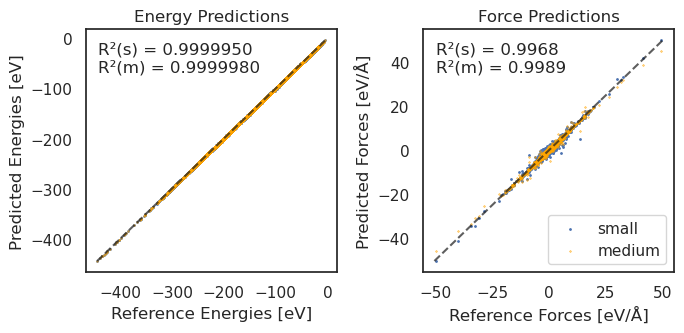

In [8]:
# Create subplot with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5))

# Energy plot (left subplot)
ax1.scatter(ref_energies_small, pred_energies_small, s=1)
ax1.scatter(
    ref_energies_medium,
    pred_energies_medium,
    s=1,
    alpha=0.5,
    color="orange",
    marker="x",
)

# Calculate R² score
r2_small = r2_score(ref_energies_small, pred_energies_small)
r2_medium = r2_score(ref_energies_medium, pred_energies_medium)

# Add text box with R² score
ax1.text(
    0.05,
    0.95,
    f"R²(s) = {r2_small:.7f}\nR²(m) = {r2_medium:.7f}",
    transform=ax1.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# Add dashed black diagonal line x=y
min_val = min(min(ref_energies_small), min(pred_energies_small))
max_val = max(max(ref_energies_small), max(pred_energies_small))
ax1.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.7)

# Add axis labels
ax1.set_xlabel("Reference Energies [eV]")
ax1.set_ylabel("Predicted Energies [eV]")
ax1.set_title("Energy Predictions")

print("Energies (s):", r2_small)
print("Energies (m):", r2_medium)

# Forces plot (right subplot)
ref_forces_flat_small = np.concatenate(ref_forces_small).astype(float).tolist()
pred_forces_flat_small = np.concatenate(pred_forces_small).astype(float).tolist()

ref_forces_flat_medium = np.concatenate(ref_forces_medium).astype(float).tolist()
pred_forces_flat_medium = np.concatenate(pred_forces_medium).astype(float).tolist()

ax2.scatter(ref_forces_flat_small, pred_forces_flat_small, s=1, label="small")
ax2.scatter(
    ref_forces_flat_medium,
    pred_forces_flat_medium,
    s=1,
    alpha=0.5,
    color="orange",
    marker="x",
    label="medium",
)

# Calculate R² score for forces
r2_forces_small = r2_score(ref_forces_flat_small, pred_forces_flat_small)
r2_forces_medium = r2_score(ref_forces_flat_medium, pred_forces_flat_medium)

# Add text box with R² score
ax2.text(
    0.05,
    0.95,
    f"R²(s) = {r2_forces_small:.4f}\nR²(m) = {r2_forces_medium:.4f}",
    transform=ax2.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# Add dashed black diagonal line x=y
min_val = min(min(ref_forces_flat_small), min(pred_forces_flat_small))
max_val = max(max(ref_forces_flat_small), max(pred_forces_flat_small))
ax2.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.7)

# Add axis labels
ax2.set_xlabel("Reference Forces [eV/Å]")
ax2.set_ylabel("Predicted Forces [eV/Å]")
ax2.legend(loc="lower right")
ax2.set_title("Force Predictions")

print("Forces (s):", r2_forces_small)
print("Forces (m):", r2_forces_medium)

plt.tight_layout()
plt.savefig(f"{experiment}/energies_forces_scatter.png", dpi=300)
plt.show()

In [9]:
# Calculate MSE and RMSE for energies
mse_small_energy = mean_squared_error(ref_energies_small, pred_energies_small)
rmse_small_energy = root_mean_squared_error(ref_energies_small, pred_energies_small)
mse_medium_energy = mean_squared_error(ref_energies_medium, pred_energies_medium)
rmse_medium_energy = root_mean_squared_error(ref_energies_medium, pred_energies_medium)
# Calculate MSE und RMSE for forces
mse_small_forces = mean_squared_error(ref_forces_flat_small, pred_forces_flat_small)
rmse_small_forces = root_mean_squared_error(
    ref_forces_flat_small, pred_forces_flat_small
)
mse_medium_forces = mean_squared_error(ref_forces_flat_medium, pred_forces_flat_medium)
rmse_medium_forces = root_mean_squared_error(
    ref_forces_flat_medium, pred_forces_flat_medium
)
# Print results
print("Energies")
print("Small model - MSE energy:", round(mse_small_energy, 4))
print("Medium model - MSE energy:", round(mse_medium_energy, 4))
print("Small model - RMSE energy:", round(rmse_small_energy, 4))
print("Medium model - RMSE energy:", round(rmse_medium_energy, 4))
print("Forces")
print("Small model - MSE forces:", round(mse_small_forces, 4))
print("Medium model - MSE forces:", round(mse_medium_forces, 4))
print("Small model - RMSE forces:", round(rmse_small_forces, 4))
print("Medium model - RMSE forces:", round(rmse_medium_forces, 4))

# Write results to CSV file
metrics_df = pd.DataFrame(
    {
        "Model": ["GRACE small", "GRACE medium"],
        "MSE_Energy": [mse_small_energy, mse_medium_energy],
        "RMSE_Energy": [rmse_small_energy, rmse_medium_energy],
        "MSE_Forces": [mse_small_forces, mse_medium_forces],
        "RMSE_Forces": [rmse_small_forces, rmse_medium_forces],
    }
)
metrics_df.to_csv(f"{experiment}/energy_force_metrics.csv", index=False)

Energies
Small model - MSE energy: 0.0237
Medium model - MSE energy: 0.0094
Small model - RMSE energy: 0.1541
Medium model - RMSE energy: 0.0971
Forces
Small model - MSE forces: 0.0036
Medium model - MSE forces: 0.0013
Small model - RMSE forces: 0.0597
Medium model - RMSE forces: 0.0355


In [10]:
n_atoms_list = []
per_atom_energy_errors_small = []
per_atom_energy_errors_medium = []

for i, struc in enumerate(tqdm.tqdm(structures)):
    try:
        n = len(struc)
        n_atoms_list.append(n)

        per_atom_energy_errors_small.append(
            abs(ref_energies_small[i] - pred_energies_small[i]) / n
        )
        per_atom_energy_errors_medium.append(
            abs(ref_energies_medium[i] - pred_energies_medium[i]) / n
        )
    except:
        continue

print("Per Atom error (small) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_small) ** 2)) * 1000)
print("Per Atom error (medium) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_medium) ** 2)) * 1000)

# Save per-atom error results to CSV
per_atom_rmse_small = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_small) ** 2)) * 1000
per_atom_rmse_medium = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_medium) ** 2)) * 1000

per_atom_df = pd.DataFrame({
    "Model": ["GRACE small", "GRACE medium"],
    "Per_Atom_RMSE_meV": [per_atom_rmse_small, per_atom_rmse_medium]
})
per_atom_df.to_csv(f"{experiment}/per_atom_energy_errors.csv", index=False)

100%|██████████| 10000/10000 [00:00<00:00, 384114.88it/s]

Per Atom error (small) in meV:  6.681345725091932
Per Atom error (medium) in meV:  4.077629825626221
